In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline

In [6]:
data = pd.read_csv('../datasets/Mall_Customers.csv')
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [8]:
# data
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

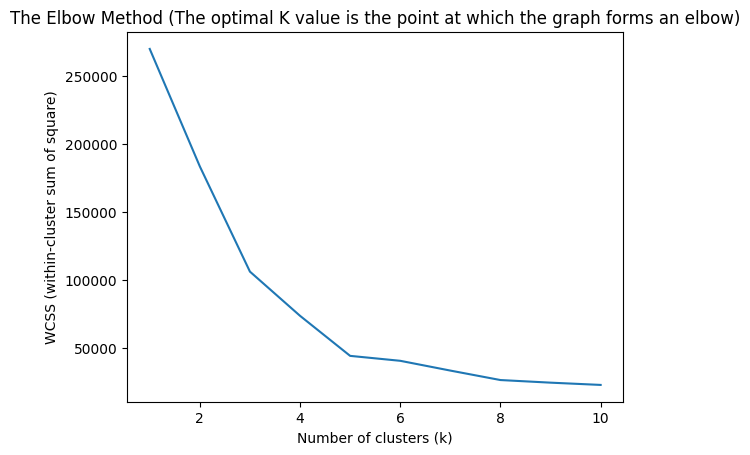

In [16]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method (The optimal K value is the point at which the graph forms an elbow)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (within-cluster sum of square)')
plt.show()

In [31]:
optimal_k = 5
pipeline = Pipeline([
    ('scalar', StandardScaler()), 
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=42)),
])

pipeline.fit(X)
cluster_labels = pipeline.predict(X)

scaler = pipeline.named_steps['scalar']
kmeans = pipeline.named_steps['kmeans']

# result 
labels = kmeans.labels_
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

# metrics
inertia = kmeans.inertia_
silhouette_avg = silhouette_score(X, labels)

data['cluster_label'] = cluster_labels

print(silhouette_avg)

0.553931997444648


In [24]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_label
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


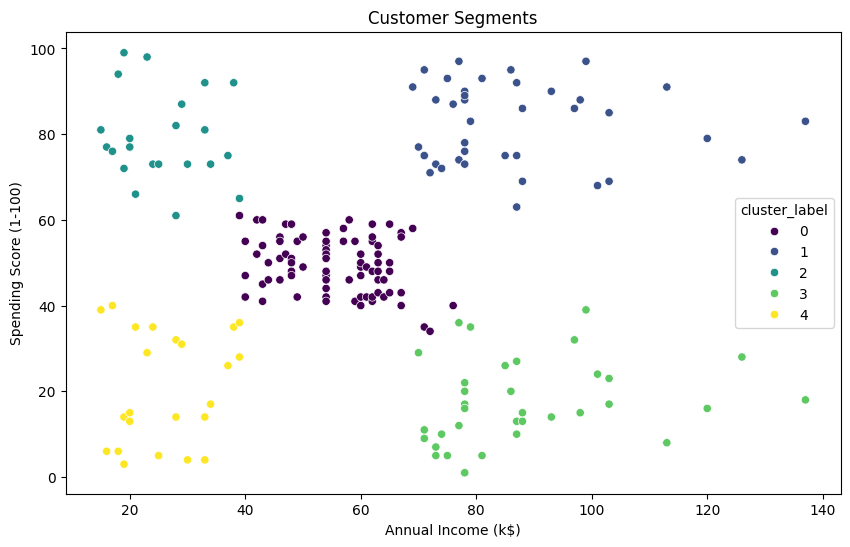

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster_label', data=data, palette='viridis')
plt.title('Customer Segments')
plt.show()